In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shitiz.Practical1_ActivationF import comparison_functions

In [4]:
x = np.linspace(-6,6,1000)

In [12]:
def plot_func_and_deri(name,function,derivative,x_values=x):
    y = function(x_values)
    dy = derivative(x_values)
    plt.figure(figsize=(10,5))
    plt.plot(x_values,y,label="original function")
    plt.plot(x_values,dy,label="derivative")
    plt.axhline(0)
    plt.axvline(0)
    plt.title(name)
    plt.grid()
    plt.legend()
    plt.show()

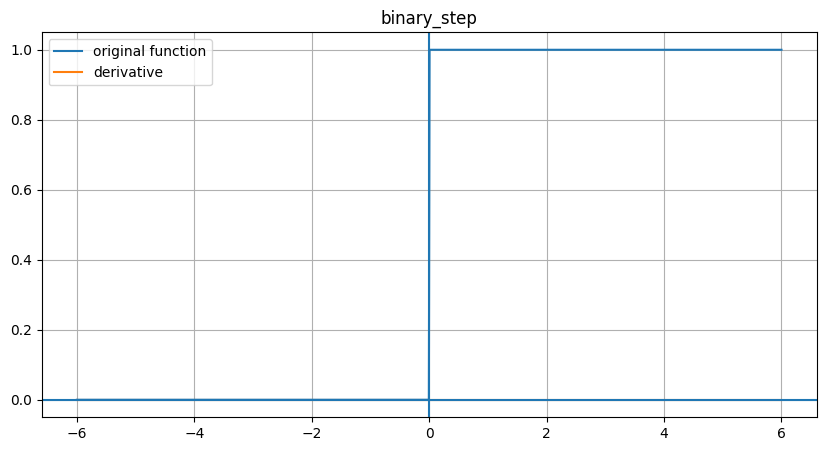

In [13]:
#BINARY FUNCTION

def binary_step(z):
    return np.where(z>=0,1.0,0.0)

def binary_step_dy(z):
    return np.zeros_like(z)

plot_func_and_deri("binary_step",binary_step,binary_step_dy)

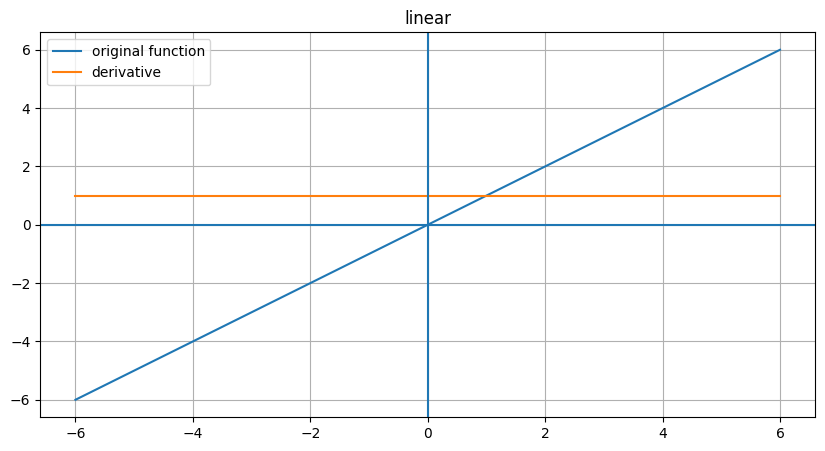

In [15]:
#linear function

def linear(z):
    return z
def linear_dy(z):
    return np.ones_like(z)
plot_func_and_deri("linear",linear,linear_dy)

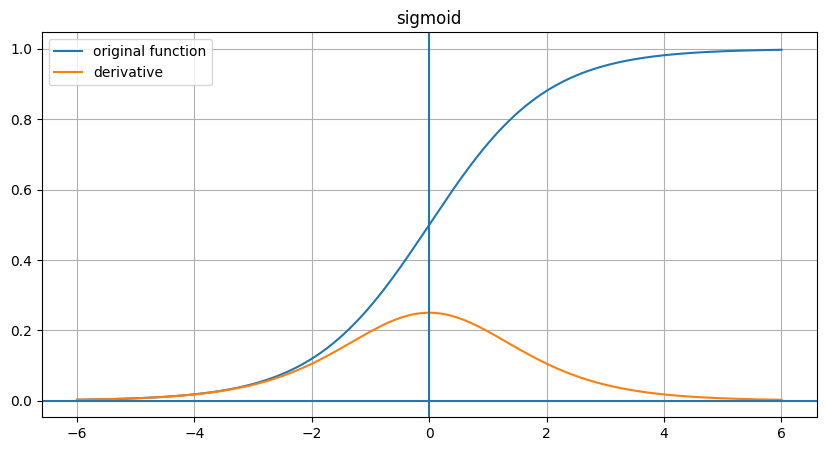

In [17]:
def sigmoid(z):
    z=np.asarray(z,dtype=float)
    return 1.0/(1.0+np.exp(-z))
def sigmoid_dy(z):
    s = sigmoid(z)
    return s*(1.0-s)
plot_func_and_deri("sigmoid",sigmoid,sigmoid_dy)

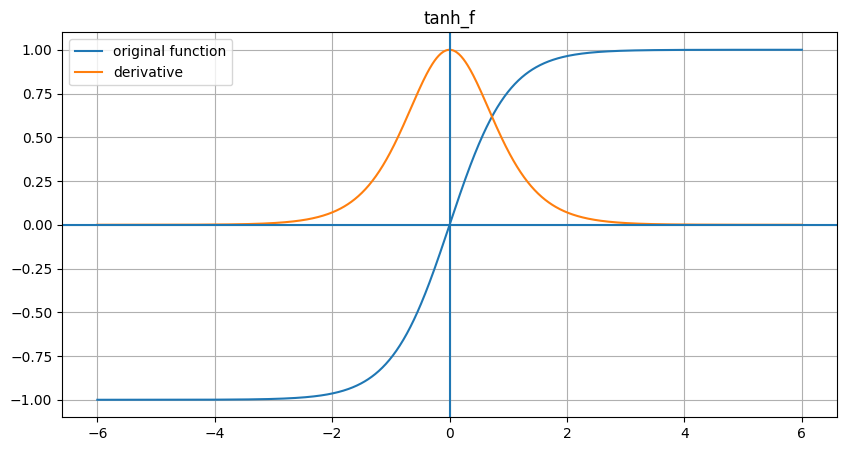

In [19]:
def tanh_f(z):
    return np.tanh(z)
def tanh_dy(z):
    return 1.0-np.tanh(z)**2
plot_func_and_deri("tanh_f",tanh_f,tanh_dy)

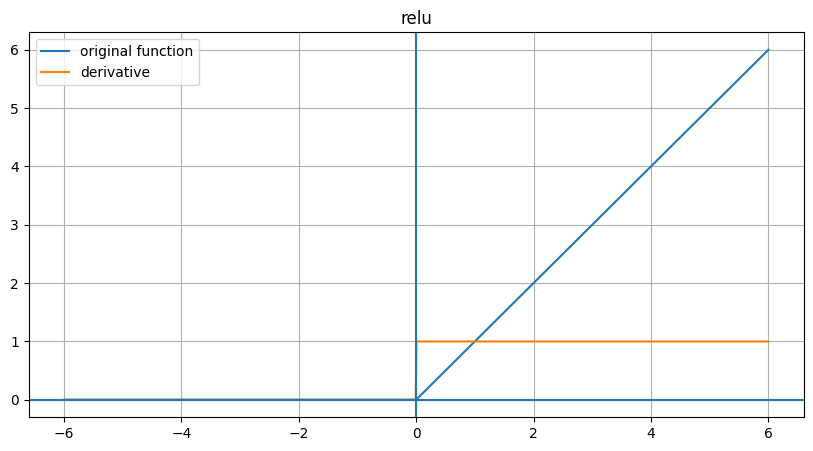

In [20]:
def relu(z):
    return np.maximum(0.0,z)
def relu_dy(z):
    return np.where(z<0,0.0,1.0)
plot_func_and_deri("relu",relu,relu_dy)

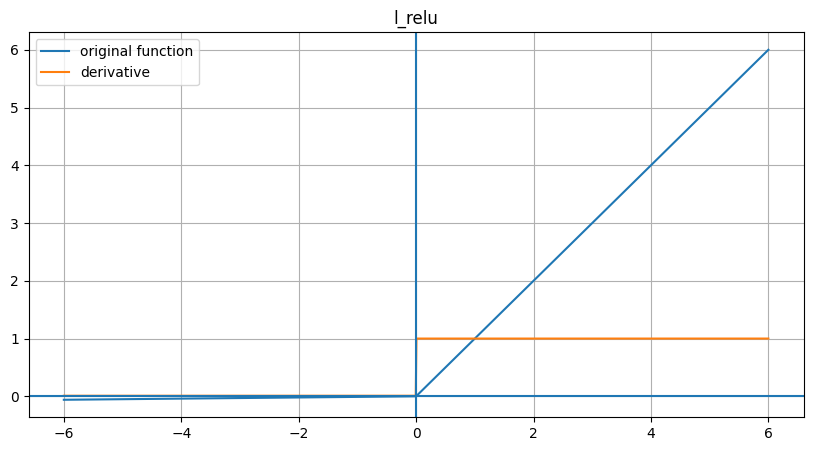

In [24]:
alpha = 0.01
def l_relu(z):
    return np.where(z>=0,z,alpha*z)
def l_relu_dy(z):
    return np.where(z>0,1.0,alpha)
plot_func_and_deri("l_relu",l_relu,l_relu_dy)

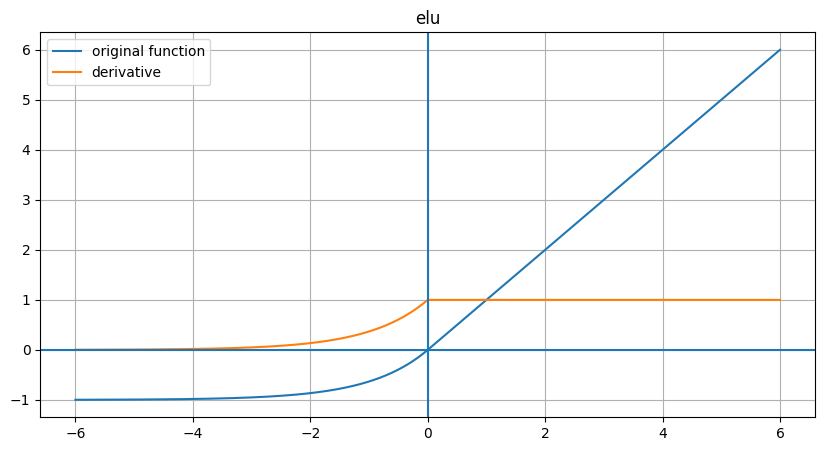

In [30]:
e_a = 1.0

def elu(z):
    return np.where(z>0,z,e_a*(np.exp(z)-1.0))
def elu_dy(z):
    return np.where(z>0,1.0,e_a *np.exp(z))
plot_func_and_deri("elu",elu,elu_dy)

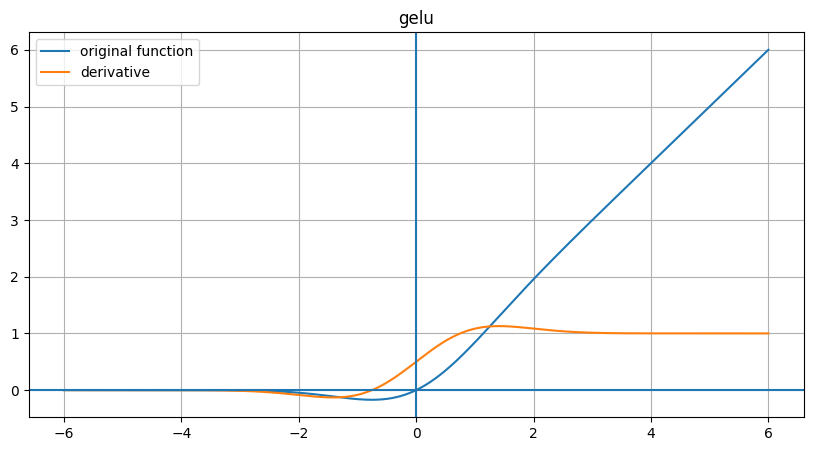

In [33]:
from scipy.stats import norm
from scipy.special import ndtr

def gelu(z):
    return z*ndtr(z)
def gelu_dy(z):
    return ndtr(z)+z*norm.pdf(z)
plot_func_and_deri("gelu",gelu,gelu_dy)

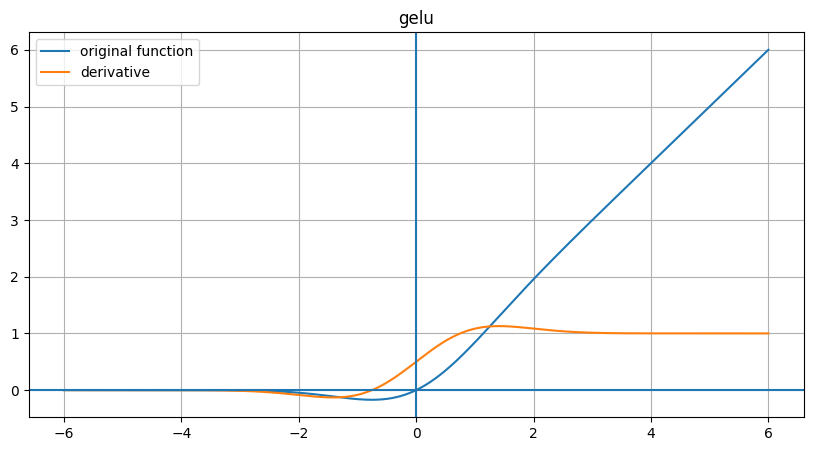

In [27]:
def normal_cdf(z):
    values = np.vectorize(math.erf)(z/np.sqrt(2.0))
    return 0.5 * (1.0+ values)
def normal_pdf(z):
    return np.exp(-0.5*z**2)/np.sqrt(2*np.pi)
def gelu(z):
    return z*normal_cdf(z)
def gelu_dy(z):
    return normal_cdf(z) + z*normal_pdf(z)
plot_func_and_deri("gelu",gelu,gelu_dy)

In [29]:
def softmax(logits):
    logits = np.asarray(logits,dtype=float)
    shifted = logits - max(logits)
    exp_values = np.exp(shifted)
    return exp_values/exp_values.sum()
def s_jacobian(logits):
    probabilities = softmax(logits)
    return np.diag(probabilities)-np.outer(probabilities,probabilities)
logits = np.array([2.0,1.0,0.1])
probabilities = softmax(logits)
jacobian = s_jacobian(logits)

print(logits)
print(probabilities)
print(probabilities.sum())
print(jacobian)


[2.  1.  0.1]
[0.65900114 0.24243297 0.09856589]
1.0
[[ 0.22471864 -0.1597636  -0.06495503]
 [-0.1597636   0.18365923 -0.02389562]
 [-0.06495503 -0.02389562  0.08885066]]


In [ ]:
comparison_functions = {
    "sigmoid": sigmoid,

}